# Reed–Solomon: del mensaje a una palabra de símbolos de varios bits

**Tema 3 · Apartado 3.2 · Demostración orientativa: 10–15 minutos.**

Codificar un mensaje con el generador dado y observar que cada coeficiente es un símbolo
completo de GF(16) o GF(4), representado por cuatro o dos bits, respectivamente.

## Cómo experimentar

Ejecuta todas las celdas en orden. Cambia el mensaje, predice qué ocurrirá y vuelve a ejecutar
el cuaderno completo. En Jupyter usa **Kernel → Restart Kernel and Run All Cells**;
en Colab, **Entorno de ejecución → Ejecutar todas**.

Los comentarios `#@param` permiten formularios en Colab; en Jupyter puedes editar los valores.
El mensaje se escribe como una lista de coeficientes, desde m0 al de mayor grado: por ejemplo,
`1, a` significa m(x) = 1 + αx. Se admiten 0, 1, a y a^j (también α y α^j).
Los coeficientes finales que falten se completan con ceros. Para **GF(4)** escribe un solo
coeficiente, por ejemplo `a`; en el RS(3,1) solo cabe un símbolo de mensaje.

No se necesitan datos externos. Las salidas guardadas corresponden a los parámetros originales.

## Modelo: dos polinomios con funciones distintas

El campo establece **cómo operar con los símbolos**. El generador establece **qué palabras forman el código**.

- **GF(16), símbolos de cuatro bits.** El campo se construye con $p(z)=z^4+z+1$, de modo que $\alpha^4=1+\alpha$.
  El código RS(15,13) utiliza el generador dado $g(x)=x^2+\alpha^5x+\alpha^3$.
- **GF(4), símbolos de dos bits.** El campo se construye con $p(z)=z^2+z+1$, de modo que $\alpha^2=1+\alpha$.
  El código RS(3,1) utiliza el generador dado $g(x)=x^2+x+1$.

En ambos casos, $\alpha$ es el elemento representado por $z$ en el campo construido con $p(z)$:
**no es una incógnita** ni hay que asignarle un número real. Usamos $z$ para describir la
aritmética de los símbolos y $x$ para indicar posiciones de la palabra. En el caso de GF(16),
$\alpha^8x^2$ coloca el símbolo de valor $\alpha^8$ en la posición de coeficiente 2.

La forma de codificar es la **no sistemática** de la teoría:
$$c(x)=m(x)g(x).$$
Hay $k$ coeficientes de mensaje y $n$ de palabra, con $n=k+2$.
En GF(16), 13 símbolos de información (52 bits) producen 15 símbolos (60 bits).
Los ceros que completan el mensaje también son posiciones de ese bloque: no lo acortamos.
En GF(4), un símbolo de dos bits produce tres símbolos, es decir, seis bits.

En un **BCH binario**, α puede intervenir al construir el generador, pero los símbolos codificados
siguen siendo bits. Elegimos Reed–Solomon para observar un caso en el que los propios símbolos
que se codifican y transmiten pertenecen al campo de varios bits.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False})

## Parámetros

Empieza por GF(16) y el mensaje 1, a, que reproducen el ejemplo de teoría.
Para cambiar a GF(4), cambia también el mensaje a un único coeficiente, como a.

In [2]:
#@title Parámetros
campo = "GF(16)" #@param ["GF(16)", "GF(4)"]
mensaje = "1, a" #@param {type:"string"}
assert campo in ["GF(16)","GF(4)"]

## 1. Representar un símbolo completo con bits

En GF($2^\ell$), un símbolo se escribe $a_0+a_1\alpha+\cdots+a_{\ell-1}\alpha^{\ell-1}$,
con coeficientes binarios. Mostramos los bits en el orden de la teoría, **$(a_0,a_1,\ldots)$**:
el término independiente está a la izquierda. Así, en GF(16), $1\leftrightarrow1000$ y
$\alpha\leftrightarrow0100$; en GF(4), $\alpha\leftrightarrow01$.

La suma es XOR de estos bits. Para multiplicar, se multiplican los polinomios de los símbolos
y se reduce con $p(z)$. **No es aritmética entera módulo 16 ni módulo 4.**

El programa almacena los bits en un entero como máscara: su valor decimal es solo una
forma de almacenamiento. La tabla y la palabra final muestran el orden $(a_0,a_1,\ldots)$.

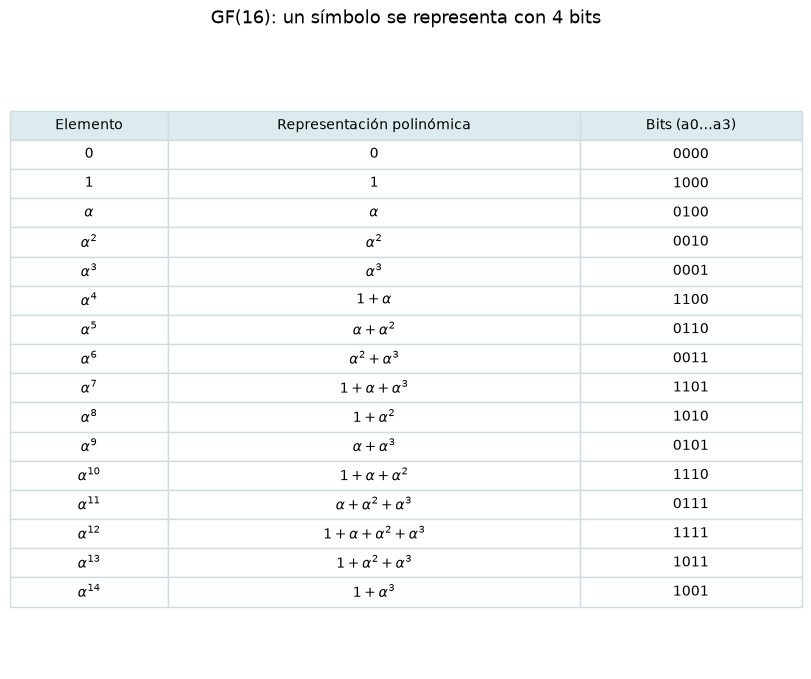

In [3]:
ell,p,n,k = {"GF(16)":(4,0b10011,15,13),"GF(4)":(2,0b111,3,1)}[campo]
q = 2**ell

def gf_mul(a,b):
    """Producto de símbolos: polinomios binarios reducidos por p(z)."""
    resultado = 0
    while b:
        if b & 1:
            resultado ^= a
        b >>= 1
        a <<= 1
        if a & q:
            a ^= p
    return resultado

# Tabla de potencias de α; α se almacena como el coeficiente de z.
potencias = [1]
for _ in range(q-2):
    potencias.append(gf_mul(potencias[-1],2))
exponente = {valor:j for j,valor in enumerate(potencias)}

def bits_simbolo(valor):
    return ''.join(str((valor >> j) & 1) for j in range(ell))

def etiqueta(valor):
    if valor == 0: return '0'
    if valor == 1: return '1'
    j = exponente[valor]
    return r'\alpha' if j == 1 else r'\alpha^{'+str(j)+'}'

def polinomio_simbolo(valor):
    terminos=[]
    for j in range(ell):
        if (valor >> j) & 1:
            terminos.append('1' if j == 0 else ('α' if j == 1 else f'α^{{{j}}}'))
    return ' + '.join(terminos) if terminos else '0'

valores = [0]+potencias
filas = [[f'${etiqueta(v)}$','$'+polinomio_simbolo(v)+'$',bits_simbolo(v)] for v in valores]
fig,ax = plt.subplots(figsize=(8,1.4+.33*q),layout="constrained")
ax.axis('off')
tabla = ax.table(cellText=filas,colLabels=['Elemento','Representación polinómica',f'Bits (a0…a{ell-1})'],
                 cellLoc='center',colLoc='center',loc='center',colWidths=[.2,.52,.28])
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1,1.45)
for (fila,col),celda in tabla.get_celld().items():
    celda.set_edgecolor('#cfdde1')
    if fila == 0: celda.set_facecolor('#dcebed')
ax.set_title(f'{campo}: un símbolo se representa con {ell} bits',pad=18)
plt.show()

## 2. Escribir el mensaje y el generador

Las listas tienen **coeficientes en orden creciente**: la primera entrada corresponde al
termino independiente; la segunda, al de $x$; la tercera, al de $x^2$, etc.
El mensaje puede utilizar cualquier elemento del campo en cada posición.

Los generadores dados también pueden escribirse como $(x+\alpha)(x+\alpha^2)$.
En GF(16), $\alpha+\alpha^2=\alpha^5$ y $\alpha\alpha^2=\alpha^3$.
En GF(4), $\alpha+\alpha^2=1$ y $\alpha\alpha^2=1$.

In [4]:
def leer_simbolo(texto):
    texto = texto.strip().lower().replace('α','a').replace('alpha','a').replace(' ','')
    if texto in ['0','1']: return int(texto)
    patron = re.fullmatch(r'a(?:\^(\d+))?',texto)
    if not patron:
        raise ValueError(f'Símbolo no válido: {texto}. Usa 0, 1, a o a^j.')
    j = 1 if patron.group(1) is None else int(patron.group(1))
    return potencias[j % (q-1)]

def latex_polinomio(coeficientes):
    terminos=[]
    for i,a in enumerate(coeficientes):
        if a == 0: continue
        simbolo = etiqueta(a)
        posicion = '' if i == 0 else ('x' if i == 1 else 'x^{'+str(i)+'}')
        terminos.append((simbolo+' '+posicion).strip() if (i == 0 or a != 1) else posicion)
    return ' + '.join(terminos) if terminos else '0'

tokens = mensaje.split(',')
if len(tokens)>k:
    raise ValueError(f'En {campo}, el RS({n},{k}) admite como máximo {k} coeficientes. Cambia el mensaje.')
m = [leer_simbolo(t) for t in tokens]+[0]*(k-len(tokens))
g = [potencias[3],potencias[5],1] if ell == 4 else [1,1,1]
display(Markdown(f'**Mensaje:** $m(x)={latex_polinomio(m)}$.\n\n'
                 f'**Generador dado:** $g(x)={latex_polinomio(g)}$.'))

**Mensaje:** $m(x)=1 + \alpha x$.

**Generador dado:** $g(x)=\alpha^{3} + \alpha^{5} x + x^{2}$.

## 3. Multiplicar y sumar los términos en el campo

### 3.1. Cómo se suman y se multiplican los símbolos

En **GF(16)**, cada símbolo se representa mediante cuatro bits, en el orden
$(a_0,a_1,a_2,a_3)$ que hemos usado en el apartado 1:
$$a_0+a_1\alpha+a_2\alpha^2+a_3\alpha^3\quad\longleftrightarrow\quad a_0a_1a_2a_3.$$
Los bits de un símbolo son sus coeficientes binarios; no se interpreta el grupo como un entero para operar módulo 16.

**Suma.** Se suman los coeficientes de cada componente módulo 2: $0+0=0$, $0+1=1$ y $1+1=0$.
Por tanto, basta hacer **XOR bit a bit**. Por ejemplo, usando las representaciones de la tabla del campo:
$$\alpha^5=\alpha+\alpha^2\leftrightarrow0110,\qquad
\alpha^4=1+\alpha\leftrightarrow1100.$$
Así,
$$\alpha^5+\alpha^4=(\alpha+\alpha^2)+(1+\alpha)=1+\alpha^2=\alpha^8,$$
porque las dos apariciones de $\alpha$ se anulan. En bits, la misma suma es:
$$0110\oplus1100=1010.$$

**Multiplicación.** Se multiplican las representaciones polinómicas de los símbolos y se suman sus componentes módulo 2.
Si aparece una potencia de grado cuatro o superior, se reduce con el polinomio del campo,
$p(z)=z^4+z+1$: esto equivale a sustituir $\alpha^4$ por $1+\alpha$ hasta obtener un símbolo de cuatro componentes.
Por ejemplo,
$$\alpha\cdot\alpha^3=\alpha^4=1+\alpha\leftrightarrow1100.$$
Otro producto que necesitaremos es
$$\alpha\cdot\alpha^5=\alpha(\alpha+\alpha^2)=\alpha^2+\alpha^3=\alpha^6\leftrightarrow0011.$$
En este segundo caso no hace falta reducir: el grado ya es menor que cuatro.
Cuando los dos símbolos se escriben como potencias de $\alpha$, su producto se obtiene sumando los exponentes;
la representación de ese resultado en cuatro bits se consulta en la tabla del campo. Multiplicar por $1$ deja el símbolo igual y multiplicar por $0$ da $0$.

### 3.2. Un mensaje concreto de 52 bits

El siguiente cálculo es un **ejemplo fijo en GF(16)**. Tomamos los trece grupos de cuatro bits:

```text
1000 | 0100 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000
```

El primer grupo es $1$; el segundo es $\alpha$; los once restantes son $0$.
El **orden de los grupos** indica el coeficiente: el primero multiplica a $x^0$, el segundo a $x^1$, el tercero a $x^2$, etc.
Por tanto,
$$m(x)=1+\alpha x+0x^2+\cdots+0x^{12}=1+\alpha x.$$
No hemos reducido el tamaño del bloque: siguen siendo 13 símbolos, aunque solo dos sean distintos de cero.
Usamos el generador dado para el RS(15,13):
$$g(x)=\alpha^3+\alpha^5x+x^2.$$
La codificación consiste en calcular $c(x)=m(x)g(x)$ con la aritmética que acabamos de explicar.

### 3.3. Multiplicar cada término del mensaje por el generador

Primero multiplicamos el generador por el término $1$ del mensaje:
$$1\cdot g(x)=\alpha^3+\alpha^5x+x^2.$$
Después lo multiplicamos por el término $\alpha x$:
$$\begin{aligned}
\alpha x\cdot g(x)
&=(\alpha\cdot\alpha^3)x+(\alpha\cdot\alpha^5)x^2+\alpha x^3\\
&=\alpha^4x+\alpha^6x^2+\alpha x^3.
\end{aligned}$$
Por ejemplo, en $(\alpha x)(\alpha^5x)$, **los símbolos** se multiplican en GF(16), dando $\alpha^6$,
y **las potencias de posición** se multiplican como $x\cdot x=x^2$. El resultado es $\alpha^6x^2$.
Los once términos nulos del mensaje no aportan nada al producto.

### 3.4. Sumar los términos que tienen la misma potencia de x

Sumamos los dos resultados anteriores. El coeficiente de $x$ recibe $\alpha^5$ y $\alpha^4$;
el de $x^2$ recibe $1$ y $\alpha^6$. Los términos independiente y de $x^3$ solo reciben una aportación:
$$\begin{aligned}
c(x)&=(\alpha^3+\alpha^5x+x^2)+(\alpha^4x+\alpha^6x^2+\alpha x^3)\\
&=\alpha^3+(\alpha^5+\alpha^4)x+(1+\alpha^6)x^2+\alpha x^3.
\end{aligned}$$

La primera suma ya la hemos calculado: $\alpha^5+\alpha^4=\alpha^8$, porque $0110\oplus1100=1010$.
Para la segunda, $1\leftrightarrow1000$ y $\alpha^6\leftrightarrow0011$, por lo que
$$1000\oplus0011=1011\leftrightarrow1+\alpha^2+\alpha^3=\alpha^{13}.$$
La **palabra codificada** es, por tanto,
$$\boxed{c(x)=\alpha^3+\alpha^8x+\alpha^{13}x^2+\alpha x^3.}$$
Sus cuatro primeros símbolos, en orden de coeficiente creciente, son
$(\alpha^3,\alpha^8,\alpha^{13},\alpha)$; los once restantes son cero.
En grupos de bits:

```text
0001 | 1010 | 1011 | 0100 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000
```

Hemos pasado de **13 símbolos (52 bits)** a **15 símbolos (60 bits)**.
Las gráficas del apartado 4 permiten ver estos mismos grupos y comparar el mensaje con la palabra codificada.

## 4. La palabra de símbolos y su representación en bits

Aquí se muestra el resultado del **mensaje y el campo elegidos en los parámetros**.
Con GF(16) y el mensaje `1, a`, coincide con el cálculo fijo del apartado 3.
Con otros parámetros, el programa calcula otra palabra; el ejemplo explicado del apartado 3 se mantiene como referencia.

Cada **columna** del dibujo es un símbolo completo. Las filas indican sus componentes
binarias $a_0,a_1,\ldots$; no son posiciones distintas de la palabra RS.
Por ejemplo, cambiar de $\alpha$ a $\alpha^2$ cambia el valor de un símbolo, no su posición.

Para formar la secuencia binaria se concatenan los grupos de cada coeficiente, primero $c_0$,
después $c_1$, hasta $c_{n-1}$. Esta es la convención explícita del ejemplo.
La expansión a bits no convierte el RS en un código que corrija necesariamente un número
fijo de bits arbitrariamente distribuidos: su unidad de corrección es el símbolo.

In [5]:
# Codificar el mensaje elegido en los parámetros.
c = [0]*n
for i,mi in enumerate(m):
    for j,gj in enumerate(g):
        c[i+j] ^= gf_mul(mi,gj)

display(Markdown(f'**Palabra de código del experimento:** $c(x)={latex_polinomio(c)}$.'))

**Palabra de código del experimento:** $c(x)=\alpha^{3} + \alpha^{8} x + \alpha^{13} x^{2} + \alpha x^{3}$.

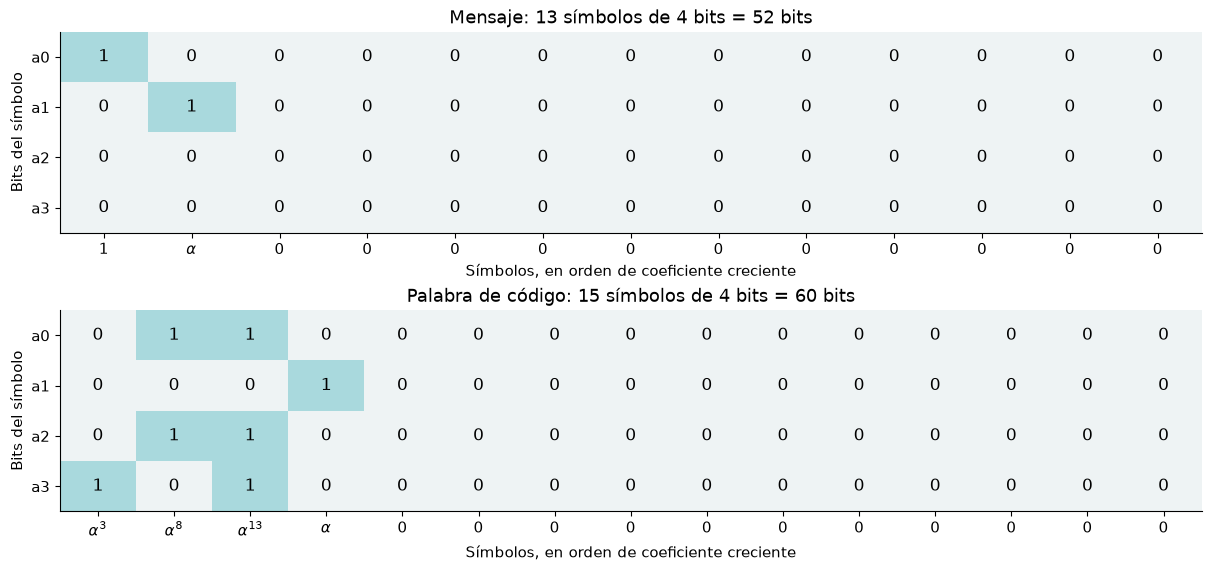

**Vector de símbolos:** $\mathbf c=(\alpha^{3}, \alpha^{8}, \alpha^{13}, \alpha, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)$.

Grupos de bits de la palabra, c0 primero:
0001 | 1010 | 1011 | 0100 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000 | 0000
Tasa de codificación: 13/15 = 0.867; dos símbolos adicionales.


In [6]:
from matplotlib.colors import ListedColormap
fig,axes = plt.subplots(2,1,figsize=(12,5.6),layout="constrained")
for ax,vector,nombre in zip(axes,[m,c],['Mensaje','Palabra de código']):
    matriz = np.array([[(a>>j)&1 for a in vector] for j in range(ell)])
    ax.imshow(matriz,cmap=ListedColormap(['#eef3f4','#a9d9dd']),vmin=0,vmax=1,aspect='auto')
    for j in range(ell):
        for i in range(len(vector)):
            ax.text(i,j,str(matriz[j,i]),ha='center',va='center',fontsize=12)
    ax.set(xticks=range(len(vector)),xticklabels=[f'${etiqueta(a)}$' for a in vector],
           yticks=range(ell),yticklabels=[f'a{j}' for j in range(ell)],
           xlabel='Símbolos, en orden de coeficiente creciente',ylabel='Bits del símbolo',
           title=f'{nombre}: {len(vector)} símbolos de {ell} bits = {len(vector)*ell} bits')
plt.show()
vector_simbolos=', '.join(etiqueta(a) for a in c)
display(Markdown(r'**Vector de símbolos:** $\mathbf c=('+vector_simbolos+r')$.'))
print('Grupos de bits de la palabra, c0 primero:')
print(' | '.join(bits_simbolo(a) for a in c))
print(f'Tasa de codificación: {k}/{n} = {k/n:.3f}; dos símbolos adicionales.')

## Antes de mirar la explicación

1. ¿Por qué α se muestra como 0100 en GF(16), y no como un único 0 o 1?
2. ¿Cuál es la diferencia entre α^8 y x^2 en el término α^8x^2?
3. Con el mensaje original 1, a, ¿cuáles son los primeros cuatro símbolos de la palabra?
4. Cambia el mensaje a 1, a^6, a^8. ¿Cuántos símbolos tiene el bloque de entrada y el de salida?
5. Elige GF(4) y mensaje a. ¿Cuál es la palabra y cuántos bits contiene?

## Explicación de lo observado

1. $\alpha$ es un elemento de GF(16), que tiene 16 valores posibles. Para representar
   cualquiera de esos valores hacen falta cuatro bits. Con la base y el orden elegidos,
   $\alpha=0+1\alpha+0\alpha^2+0\alpha^3$, por lo que su grupo es 0100.
2. $\alpha^8$ es el **valor** del símbolo; $x^2$ indica la **posición** del coeficiente.
   En este campo, ese símbolo se representa con 1010, porque $\alpha^8=1+\alpha^2$.
3. En orden creciente son $(\alpha^3,\alpha^8,\alpha^{13},\alpha)$, seguidos de once ceros.
   Sus grupos de bits son **0001 | 1010 | 1011 | 0100**, seguidos de once grupos 0000.
   Se obtiene exactamente el polinomio de la teoría:
   $$c(x)=\alpha x^3+\alpha^{13}x^2+\alpha^8x+\alpha^3.$$
4. Sigue siendo un mensaje de 13 símbolos y una palabra de 15. Ahora solo tres coeficientes
   de mensaje se han escrito explícitamente; los diez restantes son cero. No es un código acortado.
5. $c(x)=\alpha(x^2+x+1)$. Su vector es $(\alpha,\alpha,\alpha)$ y sus bits son
   **01 | 01 | 01**: tres símbolos de dos bits. α pertenece ahora a GF(4), con otra aritmética;
   no es el mismo campo que el de la representación de cuatro bits.

La codificación usada es no sistemática: los símbolos del mensaje no se copian simplemente
como un prefijo de la palabra. La multiplicación produce una palabra válida porque es múltiplo de g(x).

## Comprobación del modelo

Contrastamos el campo con identidades conocidas y reproducimos el resultado del ejemplo de teoría.

In [7]:
assert len(set(potencias)) == q-1
assert gf_mul(potencias[-1],2) == 1
assert all((a^a) == 0 and gf_mul(a,1) == a for a in range(q))
assert len(m) == k and len(c) == n
if ell == 4:
    assert potencias[4] == (1^2)
    assert bits_simbolo(2) == '0100'
    if m == [1,2]+[0]*11:
        assert c == [potencias[3],potencias[8],potencias[13],2]+[0]*11
else:
    assert potencias[2] == (1^2)
    assert bits_simbolo(2) == '01'
    assert c == [m[0],m[0],m[0]]
print('Aritmética del campo, dimensiones y resultados de referencia comprobados.')

Aritmética del campo, dimensiones y resultados de referencia comprobados.


## Referencias

Ejemplo y código propios para TDI.

- TDI, tema 3, apartado 3.2: «Cómo se construye GF(2^4)», «Ejemplo: representaciones de GF(2^4)», «Códigos Reed–Solomon» y «Ejemplo en GF(16): codificación».
- J. G. Proakis y M. Salehi, *Digital Communications*, 5.ª ed., McGraw-Hill, 2008: campos finitos y codificación de canal.